# EBITDA Leak Analysis for HoReCa Industry
## Food Cost Optimization & Waste Reduction Pipeline

### **Business Problem**
Restaurants lose 2-5% EBITDA annually due to:
- Food waste & spoilage
- Recipe deviation (over-portioning)
- Inventory inaccuracies
- Price variation tracking gaps

### **Solution**
End-to-end data pipeline that:
1. Identifies EBITDA leak sources (€ impact per ingredient)
2. Calculates theoretical vs real consumption
3. Tracks Food Cost % by dish
4. Detects pricing anomalies vs market benchmarks

### **Tech Stack**
- Python (pandas, numpy, fuzzy matching)
- Data cleaning & outlier detection
- Weighted Average Price (WAP) calculation
- Business intelligence metrics

### **Key Results**
- Total EBITDA leak February 2023: -€71.73
- FC%: 19.9% (below industry benchmark of 25–30%)
- Top waste: Burrata €791, Salmone €559, Filetto €532
- Missing WAP: 0

In [1]:
# installing thefuzz library for fuzzy matching
%pip install thefuzz

Note: you may need to restart the kernel to use updated packages.


In [2]:
# automatically reloads (autoreload) all external modules every time I run a cell 
%load_ext autoreload
%autoreload 2

# installing os, sys to load utils.py
import os
import sys

# path setup to functions file
sys.path.append(os.path.abspath('../Src'))

# istalling necessaries libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import utils as ut
from thefuzz import process, fuzz

# loading csv table files
inventory = pd.read_csv('../Data/inventory_stock.csv')
sales_pos = pd.read_csv('../Data/raw_sales_pos.csv')
recipes = pd.read_csv('../Data/recipe_book_unstandardized.csv')
invoices = pd.read_csv('../Data/supplier_invoices.csv')
benchmark = pd.read_csv('../Data/benchmark_ingredienti_horeca.csv')

# defining CONSTANT VARIABLES
PREMIUM_CATEGORIES = ['zafferano', 'tartufo', 'caviale', 'vaniglia']

# Safe categories where >€10/g is always error
SAFE_CATEGORIES = ['carni', 'verdure', 'latticini']

# Ingredients standardized dict
MAPPING_DICT = {# condimenti
                'olio ev': 'olio extravergine oliva','olio evo':'olio extravergine oliva',
                'olio evo lt': 'olio extravergine oliva', 'sale 100/kg': 'sale fino',
                # uova
                'uova 30pz': 'uova fresche', 'uova xl': 'uova fresche',
                # carne
                'fil. manzo': 'filetto di manzo',
                # pesce
                'salmone inter': 'salmone', 'salmone intero': 'salmone','salmoneo':'salmone', 
                # latticini
                'parm.regg.':'parmigiano reggiano'}

CONVERSION_MAP = {'burrata': (0.125, 'pz', 'kg'),
                  'uova':( 0.06, 'pz', 'kg'),
                  'panna fresca liquida': (1.0, ['bt', '750ml', '0.75'], 'lt')
                  }

ALLOWED_UNITS = {'kg', 'lt'}

# quick look on dfs info
print("Inventory Stock Info:")
inventory.info()
print("\nSales POS Info:")
sales_pos.info()
print("\nRecipes Info:")
recipes.info()
print("\nInvoices Info:")
invoices.info()

Inventory Stock Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   inventario_id      576 non-null    int64  
 1   data_rilevazione   576 non-null    object 
 2   prodotto           576 non-null    object 
 3   categoria          556 non-null    object 
 4   ubicazione         576 non-null    object 
 5   qty_teorica        576 non-null    float64
 6   qty_fisica         525 non-null    float64
 7   unita_misura       576 non-null    object 
 8   valore_unitario    538 non-null    float64
 9   valore_totale_eur  538 non-null    float64
 10  operatore          490 non-null    object 
 11  note_rettifica     193 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 54.1+ KB

Sales POS Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64654 entries, 0 to 64653
Data columns (total 12 columns):
 #   Column 

# DATA PROFILING

### BENCHMARK TABLE

#### Basic Cleaning

In [3]:
# applying first basic_cleaning al file benchmark, in order to match easily with inventory e invoices
benchmark_cleaned = ut.basic_cleaning(benchmark, MAPPING_DICT)

### INVENTORY TABLE

#### Checking NaN and Duplicates

In [4]:
# calling function
ut.dupli_nan_count(inventory)

No duplicates

NaN values:


inventario_id          0
data_rilevazione       0
prodotto               0
categoria             20
ubicazione             0
qty_teorica            0
qty_fisica            51
unita_misura           0
valore_unitario       38
valore_totale_eur     38
operatore             86
note_rettifica       383
dtype: int64

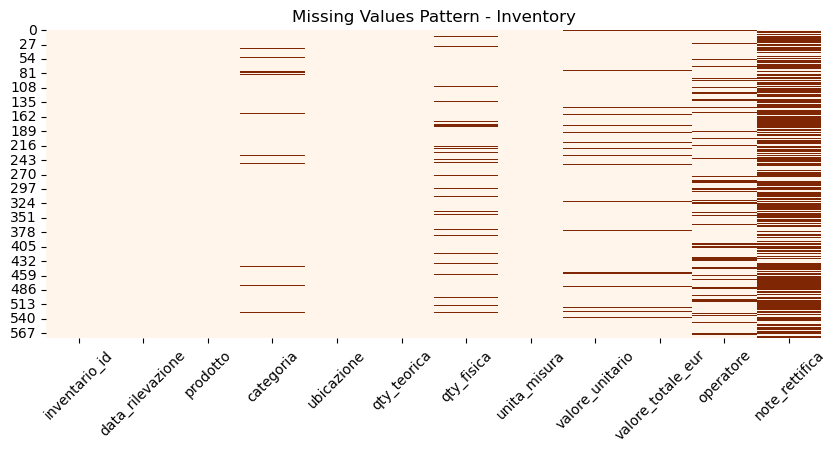

In [5]:
# NaN visual
plt.figure(figsize=(10,4))
sns.heatmap(inventory.isna(),cbar=False, cmap='Oranges')
plt.title("Missing Values Pattern - Inventory")
plt.xticks(rotation=45)
plt.show()

#### Date Accuracy

In [6]:
ut.date_accuracy(inventory, 'data_rilevazione', [2023, 2024])

0 rows out of range found.
[]


#### Basic Cleaning

In [7]:
inventory_cleaned = ut.basic_cleaning(inventory, MAPPING_DICT)


#### Fuzzy Match time

In [8]:
fuzzy_map_inventory = ut.get_best_match(inventory_cleaned['prodotto'], benchmark_cleaned['Ingrediente_Standard'], threshold=70)
inventory_cleaned['nome_standard'] = inventory_cleaned['prodotto'].map(fuzzy_map_inventory)

# checking NaN - not matched names
mask = inventory_cleaned['nome_standard'].isna()
inventory_fuzzy_nan = inventory_cleaned.loc[mask].copy()
display(inventory_fuzzy_nan.drop_duplicates(subset=['prodotto']))

Failed matches: 4/24


,inventario_id,data_rilevazione,prodotto,categoria,ubicazione,qty_teorica,qty_fisica,unita_misura,valore_unitario,valore_totale_eur,operatore,note_rettifica,anno,nome_standard
17,70018,2023-01-31,chianti docg bt,vini,dispensa,36.107,36.880,bt,6.5353,241.02,adm,NaN,2023,<NA>
18,70019,2023-01-31,tignanello,vini,bancone,14.207,15.110,bt,75.2202,1136.58,operatore,NaN,2023,<NA>
19,70020,2023-01-31,prosecco,vini,dispensa,20.365,20.365,bt,4.4152,89.92,anna,NaN,2023,<NA>
20,70021,2023-01-31,acqua nat 1l,bevande,cantina,77.497,77.497,pz,NaN,NaN,anna,NaN,2023,<NA>


#### Fixing quantities errors

In [9]:
inventory_fixed = ut.fix_unit_errors(inventory_cleaned, 'unita_misura', 'valore_unitario', 'nome_standard', 'categoria', 10, PREMIUM_CATEGORIES, SAFE_CATEGORIES)
inventory_fixed['unita_misura'].unique()

BUSINESS RULE: No unit error (g -> kg) found.


array(['kg', 'cassa', 'pz', 'l', 'lt', 'bt'], dtype=object)

#### Quantity Standardizing

In [10]:
inventory_cleaned_std = ut.standardize_quantities(inventory_fixed, qty_cols=['qty_fisica', 'qty_teorica'], unit_col='unita_misura')

# managing eggs 'cassa' quantity
cassa = inventory_cleaned_std['unita_misura'] == 'cassa'
inventory_cleaned_std.loc[cassa, ['qty_teorica','qty_fisica']] *= 1.8 
inventory_cleaned_std.loc[cassa, 'valore_unitario'] /= 1.8
inventory_cleaned_std.loc[cassa, 'unita_misura'] = 'kg'

#### Quantity Conversion

In [11]:
inventory_cleaned_std = ut.quantity_exception_manage(inventory_cleaned_std,'nome_standard', 'qty_fisica', 'unita_misura', conversion_map= CONVERSION_MAP, price_col ='valore_unitario')
inventory_cleaned_std = ut.quantity_exception_manage(inventory_cleaned_std,'nome_standard', 'qty_teorica', 'unita_misura', conversion_map= CONVERSION_MAP, price_col ='valore_unitario')

Converted 24 rows of burrata from pz to kg
No conversion applied. Verify that the names and units match.


#### Outlier Detection

inventario_id: 0 found
qty_teorica: 31 found
qty_fisica: 30 found
valore_unitario: 16 found
valore_totale_eur: 24 found


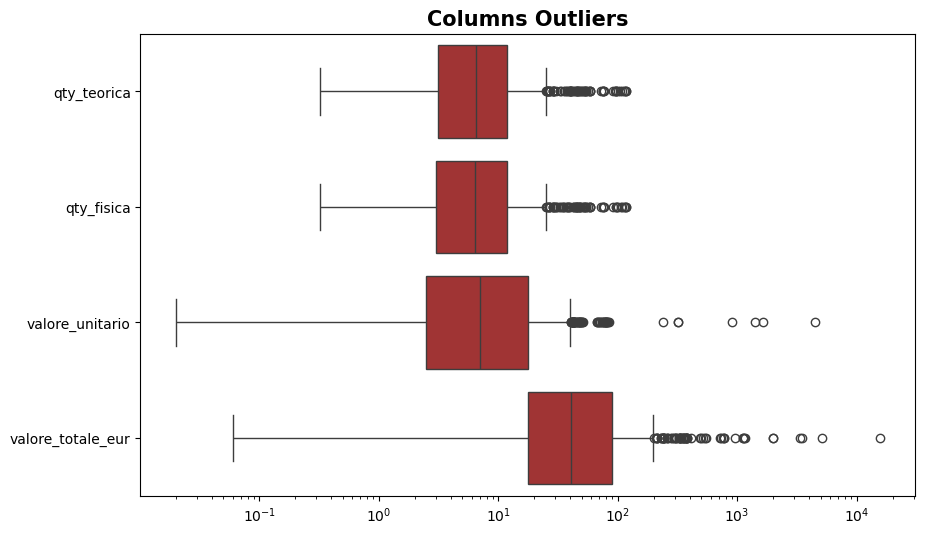

,inventario_id,data_rilevazione,prodotto,categoria,ubicazione,qty_teorica,qty_fisica,unita_misura,valore_unitario,valore_totale_eur,operatore,note_rettifica,anno,nome_standard
414,70415,2024-06-28,porcini fr.,funghi,surgelati,1.15,1.15,kg,4500.0,5175.00,mario,NaN,2024,funghi porcini freschi
275,70276,2023-12-28,parmigiano 24m,latticini,cella pesce,9.57,9.57,kg,1650.0,15783.90,luigi b.,verificato,2023,parmigiano reggiano dop 24m
341,70342,2024-03-28,vongole,pesce,cantina,3.70,3.70,kg,900.0,3330.90,NaN,verificato,2024,vongole veraci fresche
247,70248,2023-11-28,pomodorini,verdure,bancone,1.53,NaN,kg,320.0,490.88,anna,ok,2023,pomodorini ciliegino
469,70470,2024-08-28,panna fresca,latticini,dispensa,9.04,8.27,lt,240.0,1984.32,mario.r,ok,2024,panna fresca liquida


In [12]:
# calling function defined in a variable
out = ut.ouliers_auto_detection(inventory_cleaned_std, 4)

# have a quick look on outliers
inventory_cleaned_std.loc[out]

# defining new condition to exclude Beverage
food_mask = ~inventory_cleaned_std['categoria'].isin(['vini', 'bevande'])
new_mask = out & food_mask
inventory_outliers = inventory_cleaned_std.loc[new_mask].copy()
display(inventory_outliers[inventory_outliers['valore_unitario'] > 90].sort_values(ascending=False, by='valore_unitario').dropna(subset='categoria').drop_duplicates(subset=['valore_unitario']))

#### Fixing Wrong Prices

In [ ]:
# converting outliers to NaN 
inventory_cleaned_std.loc[new_mask, 'valore_unitario'] = np.nan

# extratcing prices from benchmark_table
benchmark_dict = dict(zip(benchmark_cleaned['Ingrediente_Standard'],  benchmark_cleaned['Prezzo_Benchmark_EUR']))

benchmark_price_inventory = inventory_cleaned_std['nome_standard'].map(benchmark_dict)

# telling Pandas, "Take the column, find ALL the NaNs there are, and fill them with benchmark prices."
inventory_cleaned_std['valore_unitario'] = inventory_cleaned_std['valore_unitario'].fillna(benchmark_price_inventory)

# checking how many NaNs are really left
print("Left NaN:", inventory_cleaned_std['valore_unitario'].isna().sum())

# left NaN values are beverage data, i can easily drop them
inventory_cleaned_std = inventory_cleaned_std.dropna(subset='valore_unitario')

print("Left NaN:", inventory_cleaned_std['valore_unitario'].isna().sum())

# quick view on changes
inventory_outliers_2= inventory_cleaned_std.loc[new_mask].copy()
display(inventory_outliers_2[['prodotto', 'categoria', 'unita_misura', 'valore_unitario', 'valore_totale_eur']].dropna(subset='categoria').sort_values(ascending=False, by='valore_unitario').drop_duplicates(subset=['valore_unitario']))


Left NaN: 6
Left NaN: 0


,prodotto,categoria,unita_misura,valore_unitario,valore_totale_eur
414,porcini fr.,funghi,kg,45.0,5175.00
217,costata di manzo,carni,kg,30.0,514.82
275,parmigiano 24m,latticini,kg,16.5,15783.90
341,vongole,pesce,kg,8.5,3330.90
247,pomodorini,verdure,kg,3.2,490.88
469,panna fresca,latticini,lt,2.4,1984.32


#### Descriptive Stats

In [14]:
print("INVENTORY STATS")
print(f"Period: {inventory['data_rilevazione'].min()} → {inventory['data_rilevazione'].max()}")
print(f"Unic Products: {inventory['prodotto'].nunique()}")
print(f"Average Shrinkage: {(inventory['qty_fisica'] - inventory['qty_teorica']).mean():.2f}")

# Distribuzione per categoria
print("\n Products per Category:")
print(inventory['categoria'].value_counts())

INVENTORY STATS
Period: 2023-01-31 → 31/01/2023
Unic Products: 24
Average Shrinkage: 0.21

 Products per Category:
categoria
Latticini     115
Carni          70
Secchi         70
Vini           70
Pesce          69
Verdure        46
Bevande        46
Condimenti     46
Funghi         24
Name: count, dtype: int64


### SALES POS TABLE

#### Checking NaN and Duplicates

In [15]:
# calling function
ut.dupli_nan_count(sales_pos)

No duplicates

NaN values:


transazione_id            0
data_ora                  0
tavolo                    0
coperti                3216
item_name                 0
categoria              3277
quantita                  0
prezzo_unitario           0
totale_riga               0
operatore_id              0
modalita_pagamento    12781
note                  41832
dtype: int64

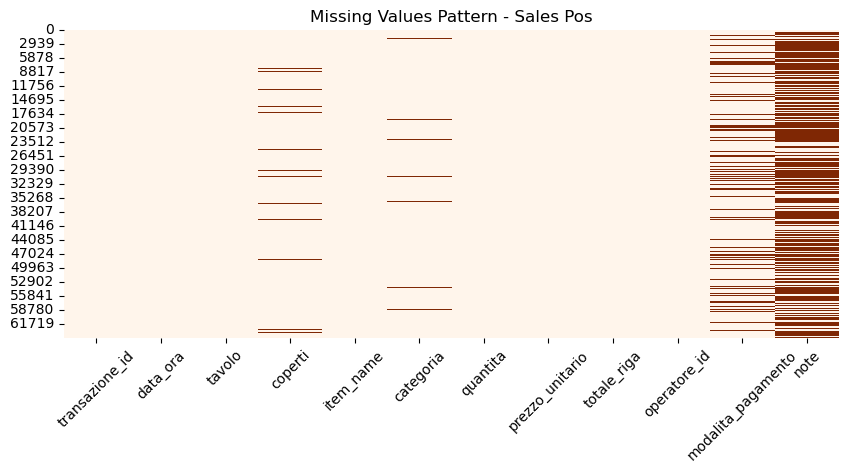

In [16]:
# NaN visual
plt.figure(figsize=(10,4))
sns.heatmap(sales_pos.isna(),cbar=False, cmap='Oranges')
plt.title("Missing Values Pattern - Sales Pos")
plt.xticks(rotation=45)
plt.show()

#### Date Accuracy

In [17]:
ut.date_accuracy(sales_pos, 'data_ora', [2023, 2024])

419 rows out of range found.
[2022 2033 2034 2025]


In [18]:
# FIXING DATA
sales_pos = sales_pos[sales_pos['anno'].isin([2023, 2024])]
sales_pos['anno'].unique()

array([2023, 2024], dtype=int32)

#### Basic Cleaning

In [19]:
sales_pos_cleaned = ut.basic_cleaning(sales_pos, MAPPING_DICT)


#### Outlier Detection

transazione_id: 0 found
coperti: 0 found
quantita: 0 found
prezzo_unitario: 3088 found
totale_riga: 1548 found


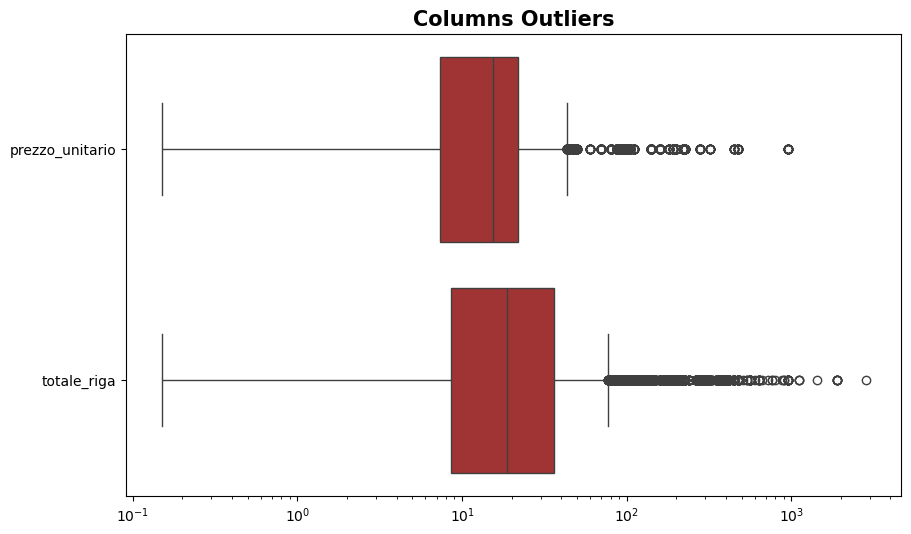

,item_name,prezzo_unitario
39250,bistecca alla fiorentina,450.0
50054,tagliata di manzo,320.0
27270,branzino al forn,280.0
20691,bistecca alla fiorentina,225.0
27277,cotoletta alla milanese,220.0
35045,spaghetti alle vongole,200.0
21163,pappardelle al cinghiale,190.0
32199,risotto ai funghi porcini,180.0
28129,tagliata di manzo,160.0
59214,ribollita toscana,140.0


In [20]:
# calling function defined in a variable
sales_pos_out = ut.ouliers_auto_detection(sales_pos_cleaned, 4)

# have a quick look on outliers
sales_pos_cleaned.loc[sales_pos_out]

# defining new condition to exclude Beverage
sales_pos_food_mask = ~(sales_pos_cleaned['item_name'].isin(['vino tignanello bottiglia', 'vino tignanello bottigli','vino chianti bottiglia']) & sales_pos_cleaned['categoria'].isin(['bevande']))
sales_new_mask = sales_pos_out & sales_pos_food_mask
sales_pos_outliers = sales_pos_cleaned.loc[sales_new_mask].copy()
sales_pos_outliers = sales_pos_outliers.dropna(subset='categoria')
display(sales_pos_outliers[(sales_pos_outliers['prezzo_unitario'] > 30) & (sales_pos_outliers['quantita'] == 1)][['item_name', 'prezzo_unitario']].sort_values(ascending=False, by='prezzo_unitario').drop_duplicates(subset=['prezzo_unitario']))

#### Descriptive Stats

SALES POS STATS
Period: 2023-01-01 12:19:00 → 2024-12-31 22:58:00
Unic Products: 46

 Products by Category:
Axes(0.125,0.11;0.775x0.77)


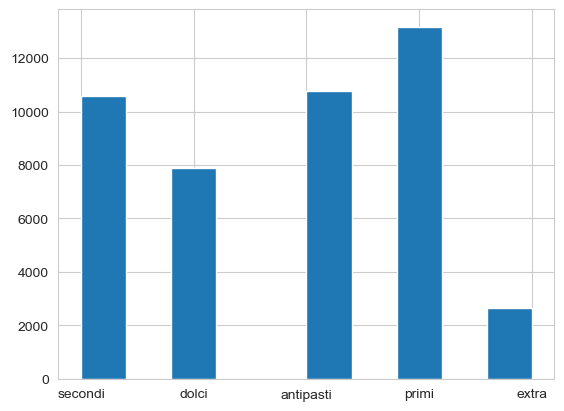

In [67]:
print("SALES POS STATS")
print(f"Period: {sales_pos_cleaned['data_ora'].min()} → {sales_pos_cleaned['data_ora'].max()}")
print(f"Unic Products: {sales_pos_cleaned['item_name'].nunique()}")

# distribution by category
print("\n Products by Category:")
print(sales_pos_cleaned['categoria'].hist())

### INVOICES TABLE

#### Checking NaN and Duplicates

In [22]:
# calling function
ut.dupli_nan_count(invoices)

No duplicates

NaN values:


fattura_id                0
riga_fattura              0
data_fattura              0
fornitore                 0
codice_fornitore          0
codice_prodotto           0
descrizione_prodotto      0
categoria               128
quantita                  0
unita_misura              0
prezzo_unitario          67
importo_totale           67
iva_pct                  72
pagato                   37
data_scadenza            77
dtype: int64

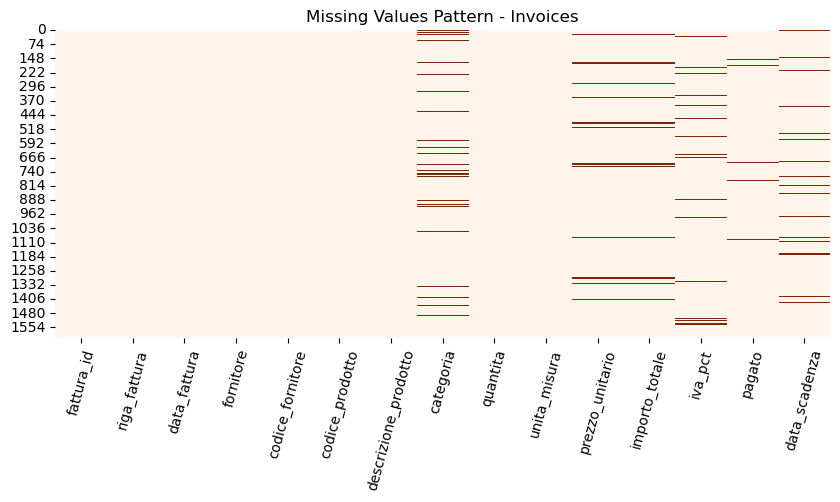

In [23]:
# NaN visual
plt.figure(figsize=(10,4))
sns.heatmap(invoices.isna(),cbar=False, cmap='Oranges')
plt.title("Missing Values Pattern - Invoices")
plt.xticks(rotation=75)
plt.show()

#### Date Accuracy

In [24]:
ut.date_accuracy(invoices, 'data_fattura', [2023, 2024])

0 rows out of range found.
[]


#### Basic Cleaning

In [25]:
invoices_cleaned = ut.basic_cleaning(invoices, MAPPING_DICT)


#### Fuzzy Match time

In [26]:
fuzzy_map_invoices = ut.get_best_match(invoices_cleaned['descrizione_prodotto'], benchmark_cleaned['Ingrediente_Standard'], threshold=70)
invoices_cleaned['nome_standard'] = invoices_cleaned['descrizione_prodotto'].map(fuzzy_map_invoices)

# checking NaN - not matched names
invoices_mask = invoices_cleaned['nome_standard'].isna()
invoices_fuzzy_nan = invoices_cleaned.loc[invoices_mask].copy()
display(invoices_fuzzy_nan[['categoria', 'descrizione_prodotto', 'unita_misura', 'prezzo_unitario', 'nome_standard']].sort_values(by='prezzo_unitario', ascending=False).drop_duplicates(subset=['descrizione_prodotto']))

Failed matches: 11/63


,categoria,descrizione_prodotto,unita_misura,prezzo_unitario,nome_standard
643,NaN,prosecco doc,bt,240.0000,<NA>
529,vini,vino tignanello,bt,89.4638,<NA>
647,bevande,acqua 1000ml,nr,17.5000,<NA>
651,vini,vino chianti docg bt,1,7.7997,<NA>
601,vini,chianti bt 0.75,750ml,7.6689,<NA>
671,vini,chianti docg,750ml,7.5580,<NA>
822,vini,chianti 75cl,0.75,7.2954,<NA>
495,NaN,acqua nat 1l,cad,0.4167,<NA>
618,bevande,acqua minerale 1l,pezzi,0.4149,<NA>
51,bevande,acqua minerale,nr,0.4100,<NA>


In [27]:
invoices_cleaned['nome_standard'].dropna()

0             olio extravergine di oliva
1                              sale fino
2       insalata mista (iceberg/lattuga)
3             olio extravergine di oliva
4             lombata di manzo (costata)
                      ...               
1604                 latte intero fresco
1605                             burrata
1607              salmone fresco filetti
1608    insalata mista (iceberg/lattuga)
1609          lombata di manzo (costata)
Name: nome_standard, Length: 1372, dtype: object

#### Fixing Quantities

In [28]:
invoices_fixed = ut.fix_unit_errors(invoices_cleaned, 'unita_misura', 'prezzo_unitario', 'descrizione_prodotto', 'categoria', 10, PREMIUM_CATEGORIES, SAFE_CATEGORIES)


BUSINESS RULE: Fixed 44 unit errors ('g' to 'kg') for products > 10€


#### Quantity Standardizing

In [29]:
invoices_cleaned_std = ut.standardize_quantities(invoices_fixed, qty_cols='quantita', unit_col='unita_misura')
invoices_cleaned_std['unita_misura'].value_counts()

unita_misura
kg    1044
pz     208
bt     186
lt     172
Name: count, dtype: int64

In [30]:
non_std = invoices_cleaned_std['unita_misura'].isin(['pz'])
invoices_cleaned_std.loc[non_std]

,fattura_id,riga_fattura,data_fattura,fornitore,codice_fornitore,codice_prodotto,descrizione_prodotto,categoria,quantita,unita_misura,prezzo_unitario,importo_totale,iva_pct,pagato,data_scadenza,anno,nome_standard
12,50004,1,2023-01-12,ortofrutta rossi e figli,forn-003,sku-8544,burrata,NaN,265.0,pz,3.1727,840.77,4.0,si,2023-03-13,2023,burrata
23,50006,1,2023-01-16,cantina vinicola toscana,forn-004,sku-9617,acqua minerale 1l,NaN,131.0,pz,NaN,NaN,22.0,0,2023-04-16,2023,<NA>
41,50008,4,2023-01-22,ortofrutta rossi e figli,forn-003,sku-8463,chianti 75cl,vini,46.0,pz,7.0985,326.53,22.0,no,2023-02-21,2023,<NA>
46,50009,2,2023-01-25,cantina vinicola toscana,forn-004,sku-4448,uova fresche,latticini,218.0,pz,0.3324,72.46,22.0,0,2023-02-24,2023,uova
47,50009,3,2023-01-25,cantina vinicola toscana,forn-004,sku-8271,burrata,latticini,144.0,pz,3.3113,476.83,22.0,si,2023-03-26,2023,burrata
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1566,50279,8,2024-12-10,pescheria del mare snc,forn-002,sku-7862,uova fresche,latticini,283.0,pz,0.3186,90.16,22.0,si,2025-02-08,2024,uova
1590,50282,8,2024-12-19,distribuzione generale,forn-008,sku-3169,acqua 1000ml,bevande,152.0,pz,NaN,NaN,5.0,si,2025-01-18,2024,<NA>
1595,50284,1,2024-12-23,ortofrutta rossi e figli,forn-003,sku-8992,burrata,latticini,189.0,pz,2.9366,555.02,22.0,si,2025-01-22,2024,burrata
1598,50284,4,2024-12-23,ortofrutta rossi e figli,forn-003,sku-2243,uova fresche cat. a,latticini,86.0,pz,0.2754,23.68,NaN,si,2025-02-21,2024,uova


#### Quantity Conversion

In [31]:
invoices_cleaned_std = ut.quantity_exception_manage(invoices_cleaned_std,'nome_standard', 'quantita', 'unita_misura', conversion_map= CONVERSION_MAP, price_col='prezzo_unitario')
non_std = invoices_cleaned_std['unita_misura'].isin(['pz'])
invoices_cleaned_std.loc[non_std]

Converted 56 rows of burrata from pz to kg
Converted 58 rows of uova from pz to kg
Converted 14 rows of panna fresca liquida from ['bt', '750ml', '0.75'] to lt


,fattura_id,riga_fattura,data_fattura,fornitore,codice_fornitore,codice_prodotto,descrizione_prodotto,categoria,quantita,unita_misura,prezzo_unitario,importo_totale,iva_pct,pagato,data_scadenza,anno,nome_standard
23,50006,1,2023-01-16,cantina vinicola toscana,forn-004,sku-9617,acqua minerale 1l,NaN,131.0,pz,NaN,NaN,22.0,0,2023-04-16,2023,<NA>
41,50008,4,2023-01-22,ortofrutta rossi e figli,forn-003,sku-8463,chianti 75cl,vini,46.0,pz,7.0985,326.53,22.0,no,2023-02-21,2023,<NA>
49,50009,5,2023-01-25,cantina vinicola toscana,forn-004,sku-7773,acqua nat 1l,bevande,156.0,pz,0.2991,46.66,22.0,no,2023-03-26,2023,<NA>
51,50010,2,2023-01-28,macelleria bianchi srl,forn-001,sku-9925,acqua minerale,bevande,86.0,pz,0.4100,35.26,22.0,1,2023-03-29,2023,<NA>
95,50019,4,2023-02-20,pescheria del mare snc,forn-002,sku-8101,vino tignanello,vini,47.0,pz,75.1429,3531.72,10.0,1,2023-05-21,2023,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1486,50265,8,2024-11-07,ortofrutta rossi e figli,forn-003,sku-2936,acqua minerale,bevande,252.0,pz,0.3195,80.51,22.0,si,2024-12-07,2024,<NA>
1493,50266,7,2024-11-08,pescheria del mare snc,forn-002,sku-8861,acqua nat 1l,bevande,222.0,pz,0.3596,79.83,10.0,no,2025-01-07,2024,<NA>
1561,50279,3,2024-12-10,pescheria del mare snc,forn-002,sku-9586,vino tignanello,vini,7.0,pz,82.0320,574.22,10.0,si,2025-02-08,2024,<NA>
1565,50279,7,2024-12-10,pescheria del mare snc,forn-002,sku-2657,acqua minerale,bevande,278.0,pz,0.3034,84.35,4.0,s,2025-03-10,2024,<NA>


#### Price Variation

#### Outlier Detection

fattura_id: 0 found
riga_fattura: 0 found
quantita: 50 found
prezzo_unitario: 55 found
importo_totale: 82 found
iva_pct: 0 found


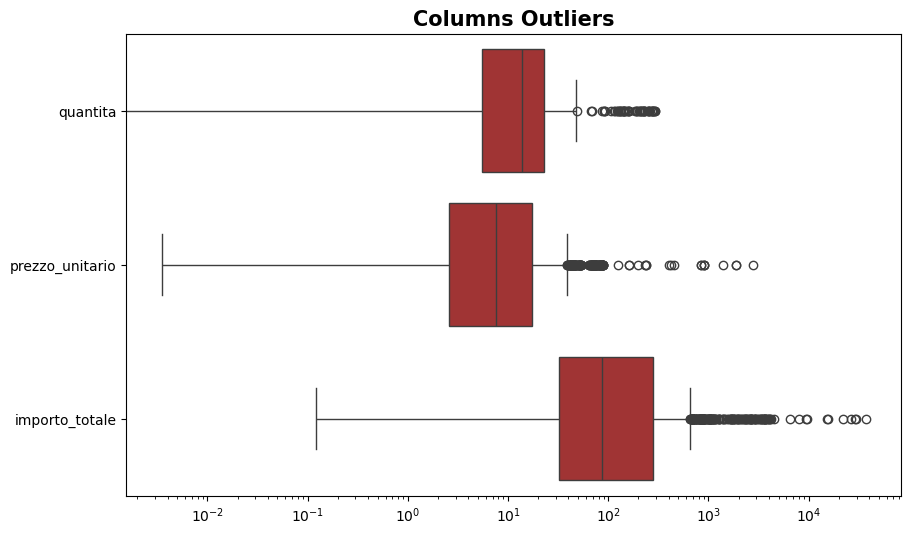

,codice_fornitore,codice_prodotto,descrizione_prodotto,categoria,quantita,unita_misura,prezzo_unitario
460,forn-008,sku-2406,costata di manzo,carni,10.59,kg,2800.000000
1081,forn-004,sku-1071,filetto di manzo,carni,19.74,kg,1900.000000
954,forn-004,sku-1561,vongole fresche,pesce,29.36,kg,900.000000
1120,forn-004,sku-6142,olio extravergine oliva,condimenti,9.51,lt,850.000000
1188,forn-005,sku-9202,vongole fresche,pesce,20.98,kg,450.000000
738,forn-003,sku-8943,petto di pollo,carni,5.33,kg,425.000000
622,forn-007,sku-6575,rucola,verdure,11.35,kg,400.000000
1048,forn-006,sku-9137,uova cat.a 30pz,latticini,15.84,kg,233.333333
1080,forn-004,sku-8506,rucola,verdure,13.39,kg,200.000000
946,forn-002,sku-9831,pomodorini ciliegino,verdure,23.29,kg,160.000000


In [32]:
# calling function defined in a variable
invoices_out = ut.ouliers_auto_detection(invoices_cleaned_std, 4)

# have a quick look on outliers
invoices_cleaned_std.loc[invoices_out]

# defining new condition to exclude Beverage
invoices_food_mask = ~invoices_cleaned_std['categoria'].isin(['bevande', 'vini'])
invoices_new_mask = invoices_out & invoices_food_mask
invoices_outliers = invoices_cleaned_std.loc[invoices_new_mask].copy()
display(invoices_outliers[['codice_fornitore', 'codice_prodotto','descrizione_prodotto', 'categoria', 'quantita', 'unita_misura', 'prezzo_unitario']][invoices_outliers['prezzo_unitario'] > 50].dropna(subset='categoria').sort_values(ascending=False, by='prezzo_unitario').drop_duplicates(subset=['prezzo_unitario']))

#### Fixing Outliers Prices

In [ ]:
# 1. converting outliers to NaN
invoices_cleaned_std.loc[invoices_new_mask, 'prezzo_unitario'] = np.nan

# 2. creating a temporary series with ALL available benchmark prices
prezzi_benchmark = invoices_cleaned_std['nome_standard'].map(benchmark_dict)

# 3. telling Pandas, "Take the column, find ALL the NaNs there are, and fill them with benchmark prices."
invoices_cleaned_std['prezzo_unitario'] = invoices_cleaned_std['prezzo_unitario'].fillna(prezzi_benchmark)

# 4. checking how many NaNs are really left
print("Left NaN:", invoices_cleaned_std['prezzo_unitario'].isna().sum())

# left NaN values are beverage data, i can easily drop them
invoices_cleaned_std = invoices_cleaned_std.dropna(subset='prezzo_unitario')

print("Left NaN:", invoices_cleaned_std['prezzo_unitario'].isna().sum())

# recalculating importo_finale
invoices_cleaned_std = invoices_cleaned_std.copy()
invoices_cleaned_std['importo_totale_pulito'] = invoices_cleaned_std['prezzo_unitario'] * invoices_cleaned_std['quantita']

Left NaN: 24
Left NaN: 0


#### Descriptive Stats

INVOICES STATS
Period: 2023-01-03 00:00:00 → 2024-12-27 00:00:00
Unic Products: 63

 Products by Category:
Axes(0.125,0.11;0.775x0.77)


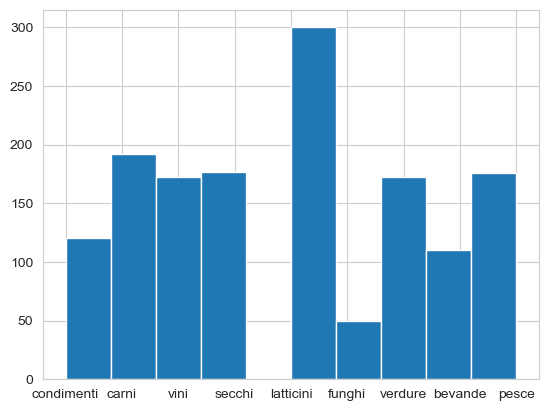

In [68]:
print("INVOICES STATS")
print(f"Period: {invoices_cleaned_std['data_fattura'].min()} → {invoices_cleaned_std['data_fattura'].max()}")
print(f"Unic Products: {invoices_cleaned_std['descrizione_prodotto'].nunique()}")

# Distribution by category:
print("\n Products by Category:")
print(invoices_cleaned_std['categoria'].hist())

### RECIPES TABLE

#### Checking NaN and Duplicates

In [35]:
# calling function
ut.dupli_nan_count(recipes)

No duplicates

NaN values:


ricetta_id                0
nome_piatto               0
ingrediente               0
quantita_per_porzione     0
unita_misura              0
note_chef                13
costo_stimato_eur         7
allergeni                46
dtype: int64

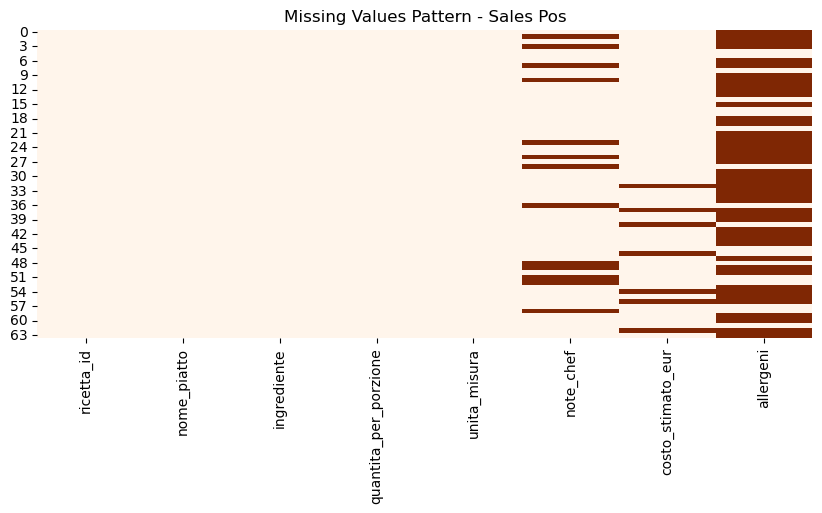

In [36]:
# NaN visual
plt.figure(figsize=(10,4))
sns.heatmap(recipes.isna(),cbar=False, cmap='Oranges')
plt.title("Missing Values Pattern - Sales Pos")
plt.show()

#### Basic Cleaning

In [37]:
recipes_cleaned = ut.basic_cleaning(recipes, MAPPING_DICT)


In [38]:
# DATA AUGMENTATION

data_augmentation = [
    # Cotoletta alla milanese
    {'nome_piatto': 'cotoletta alla milanese', 'ingrediente': 'fesa di vitello', 'quantita_per_porzione': 0.250, 'unita_misura': 'kg', 'costo_stimato_eur': 4.50},
    {'nome_piatto': 'cotoletta alla milanese', 'ingrediente': 'pangrattato', 'quantita_per_porzione': 0.060, 'unita_misura': 'kg', 'costo_stimato_eur': 0.15},
    {'nome_piatto': 'cotoletta alla milanese', 'ingrediente': 'uovo', 'quantita_per_porzione': 0.060, 'unita_misura': 'kg', 'costo_stimato_eur': 0.25},
    {'nome_piatto': 'cotoletta alla milanese', 'ingrediente': 'farina', 'quantita_per_porzione': 0.030, 'unita_misura': 'kg', 'costo_stimato_eur': 0.05},
    {'nome_piatto': 'cotoletta alla milanese', 'ingrediente': 'burro chiarificato', 'quantita_per_porzione': 0.050, 'unita_misura': 'kg', 'costo_stimato_eur': 0.60},
    
    # Tagliata di manzo
    {'nome_piatto': 'tagliata di manzo', 'ingrediente': 'controfiletto manzo', 'quantita_per_porzione': 0.300, 'unita_misura': 'kg', 'costo_stimato_eur': 7.50},
    {'nome_piatto': 'tagliata di manzo', 'ingrediente': 'rucola', 'quantita_per_porzione': 0.050, 'unita_misura': 'kg', 'costo_stimato_eur': 0.40},
    {'nome_piatto': 'tagliata di manzo', 'ingrediente': 'grana', 'quantita_per_porzione': 0.040, 'unita_misura': 'kg', 'costo_stimato_eur': 0.40},
    
    # Pappardelle al cinghiale
    {'nome_piatto': 'pappardelle al cinghiale', 'ingrediente': 'pappardelle fresche', 'quantita_per_porzione': 0.125, 'unita_misura': 'kg', 'costo_stimato_eur': 0.70},
    {'nome_piatto': 'pappardelle al cinghiale', 'ingrediente': 'ragu di cinghiale', 'quantita_per_porzione': 0.150, 'unita_misura': 'kg', 'costo_stimato_eur': 2.20},
    
    # Tagliere di salumi
    {'nome_piatto': 'tagliere di salumi', 'ingrediente': 'selezione salumi toscani', 'quantita_per_porzione': 0.150, 'unita_misura': 'kg', 'costo_stimato_eur': 3.50},
    {'nome_piatto': 'tagliere di salumi', 'ingrediente': 'sottoli', 'quantita_per_porzione': 0.050, 'unita_misura': 'kg', 'costo_stimato_eur': 0.70},
    {'nome_piatto': 'tagliere di salumi', 'ingrediente': 'pane', 'quantita_per_porzione': 0.100, 'unita_misura': 'kg', 'costo_stimato_eur': 0.30},
    
    # Bruschette miste
    {'nome_piatto': 'bruschette miste', 'ingrediente': 'pane casereccio', 'quantita_per_porzione': 0.100, 'unita_misura': 'kg', 'costo_stimato_eur': 0.30},
    {'nome_piatto': 'bruschette miste', 'ingrediente': 'pomodoro', 'quantita_per_porzione': 0.150, 'unita_misura': 'kg', 'costo_stimato_eur': 1.20},
    
    # Ribollita toscana
    {'nome_piatto': 'ribollita toscana', 'ingrediente': 'verdure', 'quantita_per_porzione': 0.200, 'unita_misura': 'kg', 'costo_stimato_eur': 1.00},
    {'nome_piatto': 'ribollita toscana', 'ingrediente': 'fagioli', 'quantita_per_porzione': 0.150, 'unita_misura': 'kg', 'costo_stimato_eur': 0.80},
    {'nome_piatto': 'ribollita toscana', 'ingrediente': 'pane raffermo', 'quantita_per_porzione': 0.100, 'unita_misura': 'kg', 'costo_stimato_eur': 0.20},
    {'nome_piatto': 'ribollita toscana', 'ingrediente': 'olio evo', 'quantita_per_porzione': 0.020, 'unita_misura': 'kg', 'costo_stimato_eur': 0.30}
]

# Creazione del DataFrame di augmentation
recipes_augmented = pd.DataFrame(data_augmentation)

# Unione con le ricette originali
recipes_cleaned_aug = pd.concat([recipes_cleaned, recipes_augmented], ignore_index=True)


In [39]:
recipes_cleaned_std = ut.standardize_quantities(recipes_cleaned_aug, qty_cols='quantita_per_porzione', unit_col='unita_misura')

#checking results
recipes_cleaned_std['unita_misura'].value_counts()

unita_misura
kg    65
lt    17
pz     1
Name: count, dtype: int64

In [40]:
# standardizing all quantities
mask = recipes_cleaned_std['unita_misura'] == 'pz'
recipes_cleaned_std.loc[mask, 'unita_misura'] = 'kg'
mask_2 = recipes_cleaned_std['ingrediente'] == 'burrata pugliese'
recipes_cleaned_std.loc[mask_2]

,ricetta_id,nome_piatto,ingrediente,quantita_per_porzione,unita_misura,note_chef,costo_stimato_eur,allergeni
40,7.0,burrata con pomodorini,burrata pugliese,0.12,kg,dop,NaN,latte


#### Fuzzy Matching

In [41]:
# appling fuzzy function
fuzzy_map_recipes = ut.get_best_match(recipes_cleaned_std['ingrediente'], benchmark_cleaned['Ingrediente_Standard'], threshold=70)
recipes_cleaned_std['nome_standard'] = recipes_cleaned_std['ingrediente'].map(fuzzy_map_recipes)

# checking NaN - not matched names
mask = recipes_cleaned_std['nome_standard'].isna()
recipes_fuzzy_nan = recipes_cleaned_std.loc[mask].copy()
display(recipes_fuzzy_nan.drop_duplicates(subset=['ingrediente']))

# dropping NaN on nome_standard and allergeni
recipes_cleaned_std.dropna(subset=['nome_standard'])

Failed matches: 10/78


,ricetta_id,nome_piatto,ingrediente,quantita_per_porzione,unita_misura,note_chef,costo_stimato_eur,allergeni,nome_standard
39,6.0,carpaccio di manzo,sale e pepe,0.00,kg,stagionale,0.0163,NaN,<NA>
68,NaN,cotoletta alla milanese,burro chiarificato,0.05,kg,NaN,0.6000,NaN,<NA>
73,NaN,pappardelle al cinghiale,ragu di cinghiale,0.15,kg,NaN,2.2000,NaN,<NA>
74,NaN,tagliere di salumi,selezione salumi toscani,0.15,kg,NaN,3.5000,NaN,<NA>
75,NaN,tagliere di salumi,sottoli,0.05,kg,NaN,0.7000,NaN,<NA>
77,NaN,bruschette miste,pane casereccio,0.10,kg,NaN,0.3000,NaN,<NA>
79,NaN,ribollita toscana,verdure,0.20,kg,NaN,1.0000,NaN,<NA>
80,NaN,ribollita toscana,fagioli,0.15,kg,NaN,0.8000,NaN,<NA>
81,NaN,ribollita toscana,pane raffermo,0.10,kg,NaN,0.2000,NaN,<NA>
82,NaN,ribollita toscana,olio evo,0.02,kg,NaN,0.3000,NaN,<NA>


,ricetta_id,nome_piatto,ingrediente,quantita_per_porzione,unita_misura,note_chef,costo_stimato_eur,allergeni,nome_standard
0,1.0,risotto ai funghi porcini,riso carnaroli,0.08,kg,qty da aggiustare,2.1472,NaN,riso carnaroli
1,1.0,risotto ai funghi porcini,porcini freschi,0.05,kg,NaN,0.9344,NaN,funghi porcini freschi
2,1.0,risotto ai funghi porcini,cipolla bianca,0.02,kg,km0,0.2452,NaN,cipolla dorata
3,1.0,risotto ai funghi porcini,brodo vegetale,0.25,lt,NaN,1.7000,NaN,brodo vegetale granulare
4,1.0,risotto ai funghi porcini,burro,0.02,kg,best quality,0.1385,latte,burro pastorizzato
...,...,...,...,...,...,...,...,...,...
70,NaN,tagliata di manzo,rucola,0.05,kg,NaN,0.4000,NaN,rucola
71,NaN,tagliata di manzo,grana,0.04,kg,NaN,0.4000,NaN,grana padano dop
72,NaN,pappardelle al cinghiale,pappardelle fresche,0.12,kg,NaN,0.7000,NaN,cozze fresche
76,NaN,tagliere di salumi,pane,0.10,kg,NaN,0.3000,NaN,pane a fette


#### Outlier Detection

ricetta_id: 0 found
quantita_per_porzione: 2 found
costo_stimato_eur: 4 found


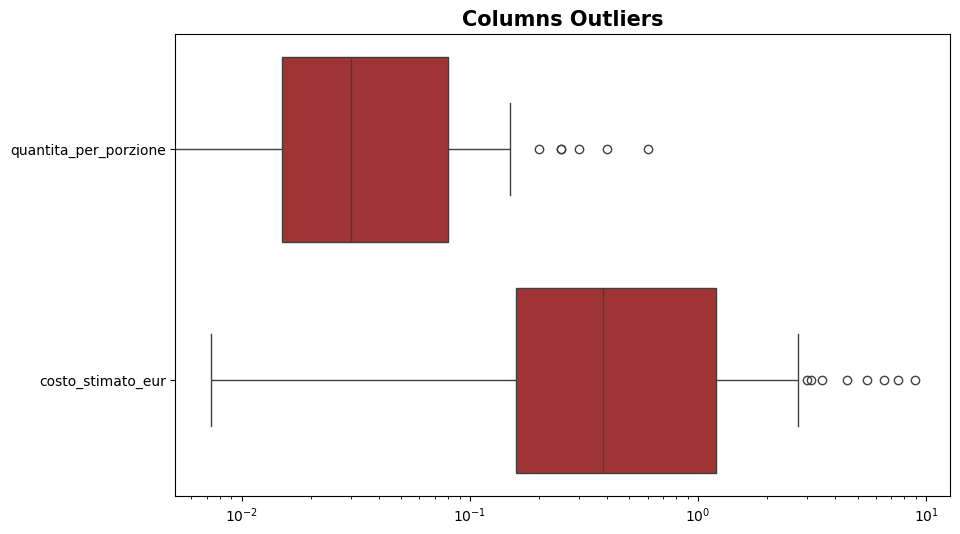

,ingrediente,quantita_per_porzione,costo_stimato_eur
28,branzino fresco intero,0.40,8.9478
69,controfiletto manzo,0.30,7.5000
23,costata t-bone manzo,0.60,6.5224
52,panna fresca liquida,0.15,5.5193


In [42]:
# calling function defined in a variable
recipes_out_mask = ut.ouliers_auto_detection(recipes_cleaned_std, 4)

# defining new condition to exclude Beverage
recipes_outliers = recipes_cleaned_std.loc[recipes_out_mask].copy()
display(recipes_outliers[['ingrediente', 'quantita_per_porzione','costo_stimato_eur']].sort_values(ascending=False, by='costo_stimato_eur').drop_duplicates(subset=['costo_stimato_eur']))

#### Managing Outrange Price

In [43]:
# managing NaN and gap in price column
recipes_cleaned_std['prezzo_benchmark_eur'] = recipes_cleaned_std['nome_standard'].map(benchmark_dict).fillna(recipes_cleaned_std['costo_stimato_eur'])

#### Descriptive Stats

In [44]:
print("RECIPES STATS")
print(f"Unic Products: {recipes_cleaned_std['ingrediente'].nunique()}")
print(f"Unic Products: {recipes_cleaned_std['nome_piatto'].nunique()}")

RECIPES STATS
Unic Products: 78
Unic Products: 16


In [45]:
# OPERATING ON RECIPES TABLE
display(recipes['ingrediente'].value_counts(dropna=False))
display(recipes['unita_misura'].value_counts(dropna=False))
display(recipes['quantita_per_porzione'].value_counts(dropna=False))

ingrediente
Sale                      3
Olio EVO                  2
Riso Carnaroli            1
Savoiardi                 1
Filetto manzo crudo       1
                         ..
Rosmarino fresco          1
Olio extravergine         1
Pepe nero macinato        1
Branzino fresco intero    1
Olio semi frittura        1
Name: count, Length: 61, dtype: int64

unita_misura
kg    45
l     14
lt     3
Kg     1
pz     1
Name: count, dtype: int64

quantita_per_porzione
0.015    8
0.020    7
0.010    6
0.005    6
0.080    4
0.001    4
0.050    4
0.040    3
0.002    3
0.060    3
0.025    2
0.003    2
0.150    2
0.030    2
0.090    2
0.600    1
0.400    1
0.120    1
0.125    1
0.250    1
0.035    1
Name: count, dtype: int64

-------------------

## EBITDA LEAK

#### Operations to final_table

In [46]:
# creating period month for "data_fattura" column, so we can group purchases correctly and avoid duplicated rows
invoices_cleaned_std = invoices_cleaned_std.copy()
invoices_cleaned_std['month'] = pd.to_datetime(invoices_cleaned_std['data_fattura']).dt.to_period('M')
# grouping invoices by nome_standard, prep table to merging
invoices_grouped = invoices_cleaned_std.groupby(['month', 'nome_standard','unita_misura']).agg({'quantita':'sum',
                                                                                    'prezzo_unitario':'mean',
                                                                                    'importo_totale_pulito':'sum'}).reset_index()

In [47]:
# filtering needed columns from inventory
inventory_filtered = inventory_cleaned_std.drop(columns=['categoria', 'ubicazione', 'operatore', 'note_rettifica'])

# adding period_M to match date between both tables
inventory_filtered['month'] = pd.to_datetime(inventory_filtered['data_rilevazione']).dt.to_period('M')

# Merging both cleaned tables 
final_table = pd.merge(inventory_filtered, invoices_grouped, how='outer', on=['nome_standard', 'month', 'unita_misura'])
final_table

,inventario_id,data_rilevazione,prodotto,qty_teorica,qty_fisica,unita_misura,valore_unitario,valore_totale_eur,anno,nome_standard,month,quantita,prezzo_unitario,importo_totale_pulito
0,70004.0,2023-01-31,branzino,1.99,2.14,kg,18.3269,39.24,2023.0,branzino fresco,2023-01,NaN,NaN,NaN
1,70028.0,2023-02-28,branzino,4.99,4.99,kg,18.2543,91.14,2023.0,branzino fresco,2023-02,11.34,18.5704,223.439448
2,70052.0,2023-03-28,branzino,1.69,2.66,kg,20.1529,53.69,2023.0,branzino fresco,2023-03,13.93,17.6004,245.173572
3,70076.0,2023-04-28,branzino,1.20,1.16,kg,18.0000,NaN,2023.0,branzino fresco,2023-04,0.05,18.0000,0.900000
4,70100.0,2023-05-28,branzino,1.10,1.10,kg,19.3656,21.30,2023.0,branzino fresco,2023-05,38.59,19.5318,786.065310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,70549.0,2024-11-28,acqua nat 1l,112.32,112.32,pz,0.3938,44.23,2024.0,<NA>,2024-11,NaN,NaN,NaN
626,70570.0,2024-12-28,chianti docg bt,51.18,51.18,bt,7.0381,360.24,2024.0,<NA>,2024-12,NaN,NaN,NaN
627,70571.0,2024-12-28,tignanello,8.68,8.68,bt,82.1032,712.49,2024.0,<NA>,2024-12,NaN,NaN,NaN
628,70572.0,2024-12-28,prosecco,28.91,28.91,bt,4.6665,134.93,2024.0,<NA>,2024-12,NaN,NaN,NaN


In [48]:
# checking NaN nature
final_table.isna().sum()
mask = final_table['nome_standard'].isna()

# nan items are baeically drinks, our focus is on food items
non_food = final_table['unita_misura'].isin(['bt', 'pz'])

# cheking if there is still any food items
non_food_items = final_table.loc[non_food]

final_table = final_table[~final_table.isin(non_food_items)]


In [49]:
# cleaning from non-match NaN
# filling the purchase gaps with 0s instead of deleting data that would distort the final result
final_table.loc[:,'quantita'] = final_table['quantita'].fillna(0)
final_table.loc[:,'prezzo_unitario'] = final_table['prezzo_unitario'].fillna(0)
final_table.loc[:,'importo_totale_pulito'] = final_table['importo_totale_pulito'].fillna(0).round(2)

# dropping NaN values
final_table = final_table.dropna(subset=['nome_standard'])

# checking possible NaN value and final table head
print("Total NaN amount:")
print(final_table.isna().sum())
print('_' * 160)
final_table

Total NaN amount:
inventario_id            35
data_rilevazione         35
prodotto                 35
qty_teorica              35
qty_fisica               80
unita_misura              0
valore_unitario          35
valore_totale_eur        68
anno                     35
nome_standard             0
month                     0
quantita                  0
prezzo_unitario           0
importo_totale_pulito     0
dtype: int64
________________________________________________________________________________________________________________________________________________________________


,inventario_id,data_rilevazione,prodotto,qty_teorica,qty_fisica,unita_misura,valore_unitario,valore_totale_eur,anno,nome_standard,month,quantita,prezzo_unitario,importo_totale_pulito
0,70004.0,2023-01-31,branzino,1.99,2.14,kg,18.3269,39.24,2023.0,branzino fresco,2023-01,0.00,0.00000,0.00
1,70028.0,2023-02-28,branzino,4.99,4.99,kg,18.2543,91.14,2023.0,branzino fresco,2023-02,11.34,18.57040,223.44
2,70052.0,2023-03-28,branzino,1.69,2.66,kg,20.1529,53.69,2023.0,branzino fresco,2023-03,13.93,17.60040,245.17
3,70076.0,2023-04-28,branzino,1.20,1.16,kg,18.0000,NaN,2023.0,branzino fresco,2023-04,0.05,18.00000,0.90
4,70100.0,2023-05-28,branzino,1.10,1.10,kg,19.3656,21.30,2023.0,branzino fresco,2023-05,38.59,19.53180,786.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,70462.0,2024-08-28,vongole,2.78,2.96,kg,9.0786,26.83,2024.0,vongole veraci fresche,2024-08,66.08,9.44320,648.72
536,70486.0,2024-09-28,vongole,3.11,3.11,kg,9.5841,29.84,2024.0,vongole veraci fresche,2024-09,9.85,8.86280,87.30
537,70510.0,2024-10-28,vongole,3.38,3.38,kg,9.8608,33.29,2024.0,vongole veraci fresche,2024-10,13.21,8.00845,104.95
538,70534.0,2024-11-28,vongole,3.12,3.12,kg,8.6940,27.10,2024.0,vongole veraci fresche,2024-11,35.19,9.72215,342.80


In [50]:
# instead of deleting columns: if I have invoices for an uncounted ingredient, stock = 0
final_table['qty_fisica'] = final_table['qty_fisica'].fillna(0)

# doing the same for the theoretical quantity, if it helps with the leakage calculations
final_table['qty_teorica'] = final_table['qty_teorica'].fillna(0) 

# recalculate the total inventory value
final_table['valore_totale_eur'] = final_table['qty_fisica'] * final_table['valore_unitario']

In [51]:
# creating the unified costing column without affecting the accounting history
final_table['prezzo_costing'] = final_table['prezzo_unitario'].fillna(final_table['nome_standard'].map(benchmark_dict))

# calculating the Leakage
final_table['leakage_eur'] = (final_table['qty_teorica'] - final_table['qty_fisica']) * final_table['prezzo_costing']

In [52]:
display(final_table)

print("_"*120 + "\nValue Counts:")

final_table['nome_standard'].value_counts()

,inventario_id,data_rilevazione,prodotto,qty_teorica,qty_fisica,unita_misura,valore_unitario,valore_totale_eur,anno,nome_standard,month,quantita,prezzo_unitario,importo_totale_pulito,prezzo_costing,leakage_eur
0,70004.0,2023-01-31,branzino,1.99,2.14,kg,18.3269,39.219566,2023.0,branzino fresco,2023-01,0.00,0.00000,0.00,0.00000,-0.000000
1,70028.0,2023-02-28,branzino,4.99,4.99,kg,18.2543,91.088957,2023.0,branzino fresco,2023-02,11.34,18.57040,223.44,18.57040,0.000000
2,70052.0,2023-03-28,branzino,1.69,2.66,kg,20.1529,53.606714,2023.0,branzino fresco,2023-03,13.93,17.60040,245.17,17.60040,-17.072388
3,70076.0,2023-04-28,branzino,1.20,1.16,kg,18.0000,20.880000,2023.0,branzino fresco,2023-04,0.05,18.00000,0.90,18.00000,0.720000
4,70100.0,2023-05-28,branzino,1.10,1.10,kg,19.3656,21.302160,2023.0,branzino fresco,2023-05,38.59,19.53180,786.07,19.53180,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,70462.0,2024-08-28,vongole,2.78,2.96,kg,9.0786,26.872656,2024.0,vongole veraci fresche,2024-08,66.08,9.44320,648.72,9.44320,-1.699776
536,70486.0,2024-09-28,vongole,3.11,3.11,kg,9.5841,29.806551,2024.0,vongole veraci fresche,2024-09,9.85,8.86280,87.30,8.86280,0.000000
537,70510.0,2024-10-28,vongole,3.38,3.38,kg,9.8608,33.329504,2024.0,vongole veraci fresche,2024-10,13.21,8.00845,104.95,8.00845,0.000000
538,70534.0,2024-11-28,vongole,3.12,3.12,kg,8.6940,27.125280,2024.0,vongole veraci fresche,2024-11,35.19,9.72215,342.80,9.72215,0.000000


________________________________________________________________________________________________________________________
Value Counts:


nome_standard
branzino fresco                     24
burrata                             24
uova                                24
salmone fresco filetti              24
sale fino                           24
rucola                              24
riso carnaroli                      24
pomodorini ciliegino                24
petto di pollo                      24
pasta fresca tagliatelle            24
parmigiano reggiano dop 24m         24
panna fresca liquida                24
olio extravergine di oliva          24
lombata di manzo (costata)          24
latte intero fresco                 24
funghi porcini freschi              24
filetto di manzo                    24
farina 00                           24
caffe                               24
vongole veraci fresche              24
insalata mista (iceberg/lattuga)    22
sale grosso marino                  12
pancetta fresca                      1
Name: count, dtype: int64

#### Operations to final_df

In [53]:
sales_pos_cleaned

,transazione_id,data_ora,tavolo,coperti,item_name,categoria,quantita,prezzo_unitario,totale_riga,operatore_id,modalita_pagamento,note,anno
0,10001,2023-01-01 19:37:00,t7,2.0,cotoletta alla milanese,secondi,1,20.79,20.79,999,satispay,NaN,2023
1,10002,2023-01-01 13:21:00,t11,2.0,vino chianti bottiglia,bevande,2,30.14,60.28,marco_2,contanti,rettifica,2023
2,10003,2023-01-01 14:39:00,t7,4.0,acqua frizzante 1l,bevande,1,3.26,3.26,anna_04,carta,NaN,2023
3,10004,2023-01-01 13:44:00,terrazza,4.0,panna cotta frutti bosco,dolci,1,7.89,7.89,marco_2,NaN,NaN,2023
4,10005,2023-01-01 13:25:00,asporto,6.0,burrata con pomodorini,antipasti,1,14.84,14.84,operatore,carta,NaN,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...
64649,74650,2024-12-31 21:49:00,t9,2.0,vino tignanello bottiglia,bevande,2,100.71,201.42,999,bancomat,errore cassa,2024
64650,74651,2024-12-31 19:52:00,t14,2.0,carpaccio di manzo,antipasti,1,17.05,17.05,marco_02,carta,NaN,2024
64651,74652,2024-12-31 19:31:00,asporto,NaN,bruschette miste,antipasti,2,9.32,18.64,marco_02,NaN,omaggio,2024
64652,74653,2024-12-31 13:00:00,asporto,2.0,bruschette miste,antipasti,1,9.55,9.55,g03,contanti,rettifica,2024


In [54]:
sales_pos_cleaned = sales_pos_cleaned[sales_pos_cleaned['categoria'] != 'bevande']

In [55]:
# merging both table in order to have an exploded table, each plate in pos has its own ingredients
final_df = pd.merge(sales_pos_cleaned, recipes_cleaned_std, left_on='item_name', right_on='nome_piatto', how='left')

# dropping useless columns
final_df = final_df.drop(columns=['tavolo', 'coperti', 'totale_riga', 'operatore_id', 'ricetta_id', 'categoria', 'modalita_pagamento', 'note', 'note_chef', 'allergeni'])

# checking NaN values
mask = final_df['prezzo_benchmark_eur'].isna()

# since nan value are at most "coperto" I easlily drop them
final_df.loc[mask].dropna() 


,transazione_id,data_ora,item_name,quantita,prezzo_unitario,anno,nome_piatto,ingrediente,quantita_per_porzione,unita_misura,costo_stimato_eur,nome_standard,prezzo_benchmark_eur


## EBITDA LEAK

In [56]:
# calling final_table e final _df, in which we have inventory/invoices and sales/recipes
print("FINAL TABLE (Inventory + Invoives) :")
display(final_table.head(1))
print("_"*170)
print("FINAL DF (Sales_POS + Recipes):")
na_mask = final_df['nome_standard'].isna()
final_df.head(1)


FINAL TABLE (Inventory + Invoives) :


,inventario_id,data_rilevazione,prodotto,qty_teorica,qty_fisica,unita_misura,valore_unitario,valore_totale_eur,anno,nome_standard,month,quantita,prezzo_unitario,importo_totale_pulito,prezzo_costing,leakage_eur
0,70004.0,2023-01-31,branzino,1.99,2.14,kg,18.3269,39.219566,2023.0,branzino fresco,2023-01,0.0,0.0,0.0,0.0,-0.0


__________________________________________________________________________________________________________________________________________________________________________
FINAL DF (Sales_POS + Recipes):


,transazione_id,data_ora,item_name,quantita,prezzo_unitario,anno,nome_piatto,ingrediente,quantita_per_porzione,unita_misura,costo_stimato_eur,nome_standard,prezzo_benchmark_eur
0,10001,2023-01-01 19:37:00,cotoletta alla milanese,1,20.79,2023,cotoletta alla milanese,fesa di vitello,0.25,kg,4.5,fegato di vitello,11.0


#### EBITDA LEAK QUANTITY COUNT

In [57]:
# 1. Calculating theorical quantity: quantità teorica utilizzata incrociando i piatti venduti con gli ingredienti per ogni piatto
final_df['total_theo_qty'] = final_df['quantita'] * final_df['quantita_per_porzione']  

# 2. Calculating theorical cost:
final_df['total_theo_cost'] = final_df['prezzo_benchmark_eur'] * final_df['total_theo_qty']
# I'd should use costo_stimato_eur from recipes table, but data are not realistic so I used benchmark price to calculate FC%

# 3. before calculating other stats it is important to group by transaction and plate
order_by_plate = final_df.groupby(['transazione_id', 'nome_piatto']).agg({
    'total_theo_cost': 'sum',      
    'prezzo_unitario': 'first',    
    'quantita': 'first'           
}).reset_index()

# 4. Calculating total_revenue
order_by_plate['total_revenue'] = order_by_plate['quantita'] * order_by_plate['prezzo_unitario']

# 5. Calculating fc% each dish
order_by_plate['theo_fc_%'] = (order_by_plate['total_theo_cost'] / order_by_plate['total_revenue']) * 100

total_fc = (order_by_plate['total_theo_cost'].sum() / 
             order_by_plate['total_revenue'].sum()) * 100

print("FC% TEORICO TOTALE")
print(f"Costo totale: €{order_by_plate['total_theo_cost'].sum():,.2f}")
print(f"Revenue totale: €{order_by_plate['total_revenue'].sum():,.2f}")
print(f"FC% TEORICO: {total_fc:.1f}%")

# STEP 6: average FC% by plate
fc_per_piatto = order_by_plate.groupby('nome_piatto')['theo_fc_%'].agg(['mean', 'std', 'count']).round(2)

print(f"\n{'-'*47}")
print("FC% PER PIATTO (su tutti gli ordini)")
print(f"{'-'*47}")
print(fc_per_piatto.sort_values('mean', ascending=False))

FC% TEORICO TOTALE
Costo totale: €271,143.70
Revenue totale: €1,362,165.93
FC% TEORICO: 19.9%

-----------------------------------------------
FC% PER PIATTO (su tutti gli ordini)
-----------------------------------------------
                            mean    std  count
nome_piatto                                   
bistecca alla fiorentina   41.29  23.56   2675
tagliata di manzo          38.65  21.96   2712
carpaccio di manzo         32.97  22.00   2760
branzino al forno          28.29  14.76   2670
tiramisu                   25.56  14.56   2723
risotto ai funghi porcini  22.90  15.55   2650
burrata con pomodorini     22.79  14.06   2721
cotoletta alla milanese    15.04  10.16   2735
panna cotta frutti bosco   12.71   8.01   2726
cannolo siciliano          11.21   8.73   2643
tagliatelle al ragu        11.21   8.03   2652
spaghetti alle vongole      8.92   7.22   2741
bruschette miste            4.97   3.40   2809
tagliere di salumi          4.32   2.42   2779
pappardelle al cingh

In [58]:
# -- 6.-- Calculating REAL CONSUMPTION vs THEORICAL CONSUMPTION
 
# 6.1 Inventory offset: View on dates datas
final_table['data_rilevazione'].value_counts().sort_index().head(5)

# 6.2.1 Filtering on opening date and closing date 
opening_inventory = final_table['data_rilevazione'] == '2023-01-31'
closing_inventory = final_table['data_rilevazione'] == '2023-02-28'

# 6.2.2 Filtering on one month in order to have all monthly invoices 
monthly_invoices = invoices_grouped[invoices_grouped['month'] == '2023-02']

# 6.3 Summing qty_fisica (inventory) in opening/closing period
sum_qty_fisica_opening = final_table[opening_inventory].groupby('nome_standard')['qty_fisica'].sum().round(2).fillna(0)
sum_qty_fisica_closing = final_table[closing_inventory].groupby('nome_standard')['qty_fisica'].sum().round(2).fillna(0)

# 6.4 Summing quantity by product
sum_quantita = monthly_invoices.groupby('nome_standard')['quantita'].sum().round(2).fillna(0)
# uso .round(2) e non :.2f nella format string perchè non è un valore singolo ma una panda serie

# 6.5 Real Consumprion: Initial Stock + Invoices - Final Stock
real_consumption = sum_qty_fisica_opening.add(sum_quantita, fill_value=0).sub(sum_qty_fisica_closing, fill_value=0)

# 6.6 Calculating Theorical Consumption: grouping data
final_df['data_ora'] = pd.to_datetime(final_df['data_ora'])
theorical_closing_inventory = (final_df['data_ora'] >= '2023-02-01') & (final_df['data_ora'] < '2023-03-01')
theorical_consumption = final_df[theorical_closing_inventory].groupby('nome_standard')['total_theo_qty'].sum().round(2).fillna(0)

# 6.7 Final count
leak_qty = real_consumption.sub(theorical_consumption, fill_value=0)
leak_qty_c = leak_qty.copy()

# 6.8 filtering by Ingredinets qty
leak_qty_c = leak_qty_c[leak_qty_c != 0.00].sort_values(ascending=False)
leak_qty_c = pd.DataFrame(leak_qty_c).reset_index().rename(columns={'index':'nome_standard', 0 :'Total_qty'})

print('Stock count Net Qty Value: Real vs Theorical:')
leak_qty_c.head(10)

Stock count Net Qty Value: Real vs Theorical:


,nome_standard,Total_qty
0,farina 00,57.09
1,pomodorini ciliegino,54.30
2,vongole veraci fresche,53.51
3,rucola,50.12
4,vino rosso da cucina,42.00
5,insalata mista (iceberg/lattuga),41.95
6,salmone fresco filetti,33.98
7,uova,33.50
8,burrata,33.49
9,petto di pollo,20.14


**Value > 0:** It's products you paid for that came out of the fridge, but didn't generate revenue (Waste/Leak).

**Value < 0:** (If this were to happen) This means you consumed less than expected. It often indicates that portions in the kitchen are smaller than what is written in the recipe (potential drop in quality).

### EBITDA LEAK EUR COUNT

In [59]:
# 1. Calculating weighted average price between quantity ordered and invoices price in order to keep price variation
wap = invoices_grouped[invoices_grouped['month'] == '2023-02'].groupby('nome_standard').agg(
    {'quantita': 'sum', 'importo_totale_pulito': 'sum'}
).round(2).reset_index()

wap['wap'] = (wap['importo_totale_pulito'] / wap['quantita']).round(2)

In [60]:
# 2. Merging wap column with leak quantity column
leak_eur = pd.merge(leak_qty_c, wap[['nome_standard', 'wap']], on='nome_standard', how='left')
missing_wap = leak_eur[leak_eur['wap'].isna()]

In [61]:
# printing results
if len(missing_wap) > 0:
    print(f"{len(missing_wap)} ingredients without WAP:")
    print(missing_wap[['nome_standard', 'Total_qty']].sort_values(by='Total_qty').head(10))

24 ingredients without WAP:
                    nome_standard  Total_qty
44       brodo vegetale granulare     -32.50
43        concentrato di pomodoro     -25.50
42              fegato di vitello     -24.00
41                  cozze fresche     -13.32
40                   pane a fette     -10.00
39  pasta secca (spaghetti/penne)      -9.81
37                     mascarpone      -8.48
36              macinato di manzo      -8.00
35                         limone      -7.61
33                 ricotta fresca      -6.42


In [62]:
# if the WAP is NaN (because there were no purchases in the month), use the benchmark price
leak_eur['wap'] = leak_eur['wap'].fillna(leak_eur['nome_standard'].map(benchmark_dict))

# calculating leak value
leak_eur['EBITDA_leak_eur'] = (leak_eur['Total_qty'] * leak_eur['wap']).round(2)

# sorting data by leak euro value
leak_eur = leak_eur.sort_values('EBITDA_leak_eur', ascending=False)

leak_eur.head()

,nome_standard,Total_qty,wap,EBITDA_leak_eur
8,burrata,33.49,23.62,791.03
6,salmone fresco filetti,33.98,16.45,558.97
12,filetto di manzo,14.68,36.23,531.86
2,vongole veraci fresche,53.51,9.67,517.44
4,vino rosso da cucina,42.00,6.43,270.06


#### Plotting Stats

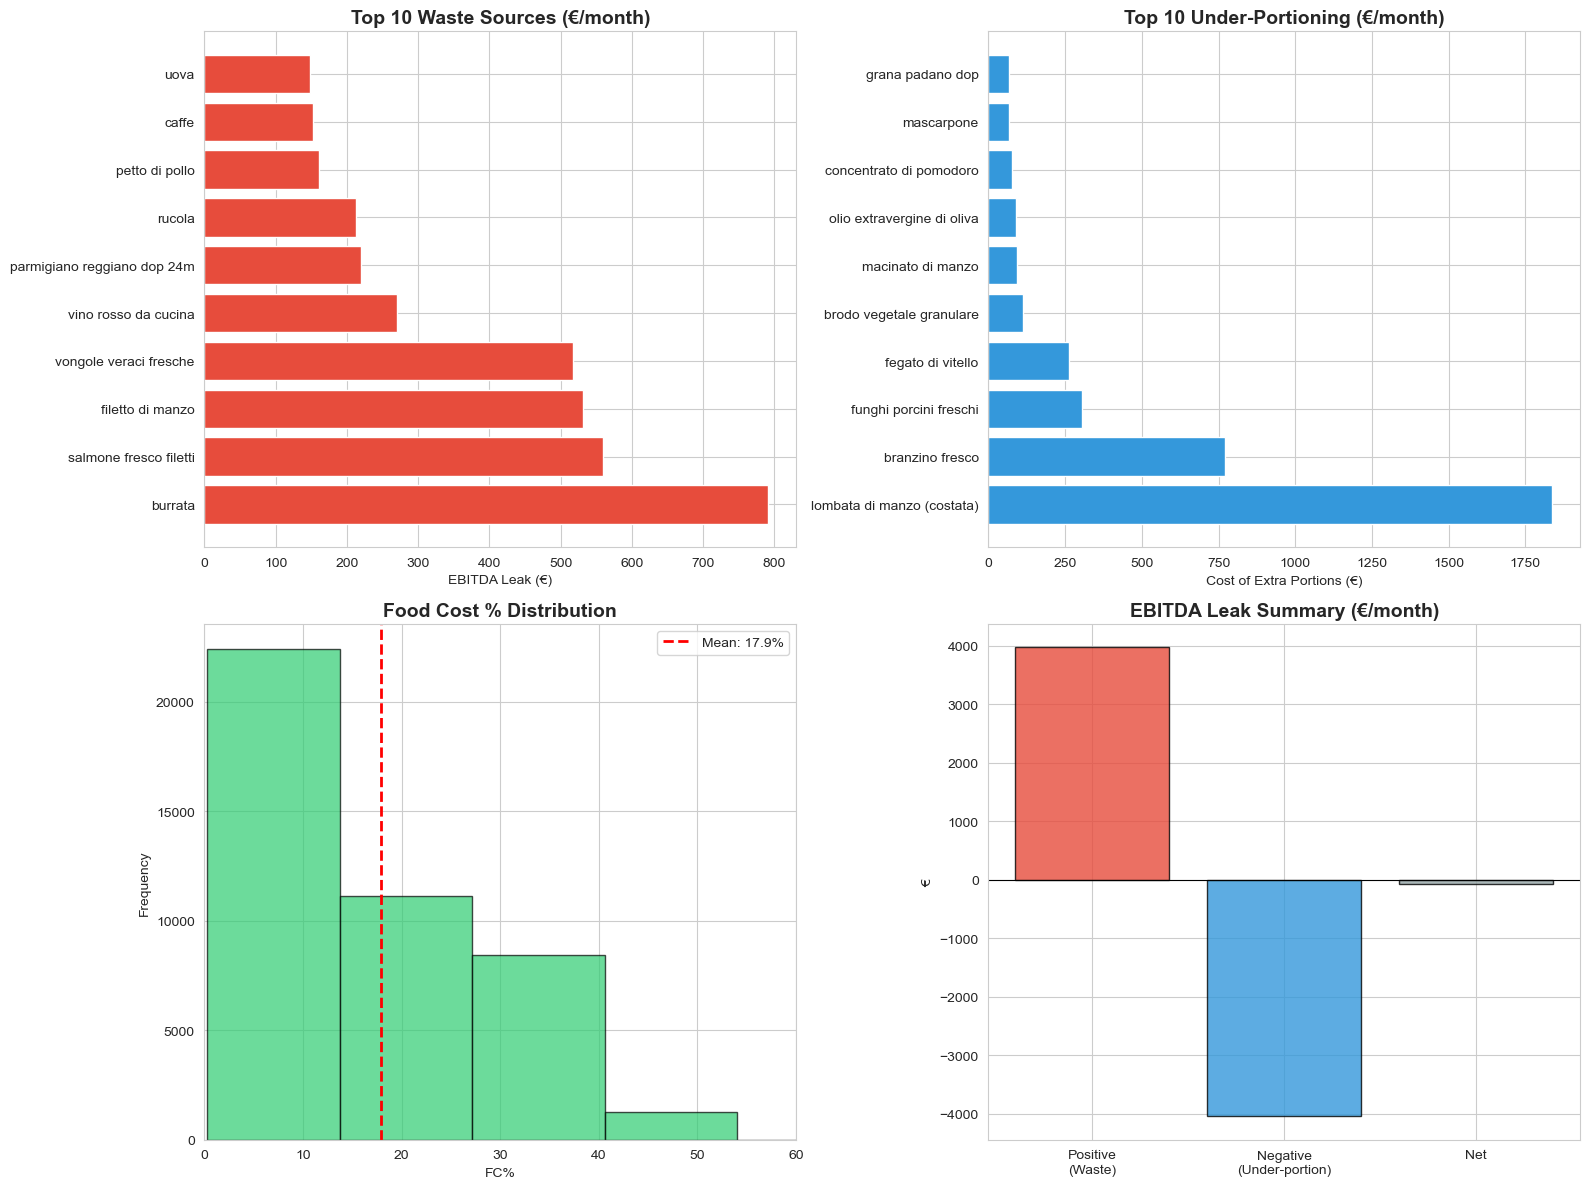

In [63]:
# Setup
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 10 EBITDA Leaks (Positive)
top_positive = leak_eur[leak_eur['EBITDA_leak_eur'] > 0].nlargest(10, 'EBITDA_leak_eur')
axes[0,0].barh(top_positive['nome_standard'], top_positive['EBITDA_leak_eur'], color='#e74c3c')
axes[0,0].set_title('Top 10 Waste Sources (€/month)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('EBITDA Leak (€)')

# 2. Top 10 Under-Portioning (Negative)
top_negative = leak_eur[leak_eur['EBITDA_leak_eur'] < 0].nsmallest(10, 'EBITDA_leak_eur')
axes[0,1].barh(top_negative['nome_standard'], abs(top_negative['EBITDA_leak_eur']), color='#3498db')
axes[0,1].set_title('Top 10 Under-Portioning (€/month)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Cost of Extra Portions (€)')

# 3. FC% Distribution by Dish
axes[1,0].hist(order_by_plate['theo_fc_%'], bins=30, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1,0].set_xlim(0, 60)
axes[1,0].axvline(order_by_plate['theo_fc_%'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {order_by_plate["theo_fc_%"].mean():.1f}%')
axes[1,0].set_title('Food Cost % Distribution', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('FC%')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

# 4. EBITDA Leak Summary
categories = ['Positive\n(Waste)', 'Negative\n(Under-portion)', 'Net']
values = [
    leak_eur[leak_eur['EBITDA_leak_eur'] > 0]['EBITDA_leak_eur'].sum(),
    leak_eur[leak_eur['EBITDA_leak_eur'] < 0]['EBITDA_leak_eur'].sum(),
    leak_eur['EBITDA_leak_eur'].sum()
]
colors = ['#e74c3c', '#3498db', '#95a5a6']
axes[1,1].bar(categories, values, color=colors, alpha=0.8, edgecolor='black')
axes[1,1].axhline(0, color='black', linewidth=0.8)
axes[1,1].set_title('EBITDA Leak Summary (€/month)', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('€')

plt.tight_layout()
plt.show()

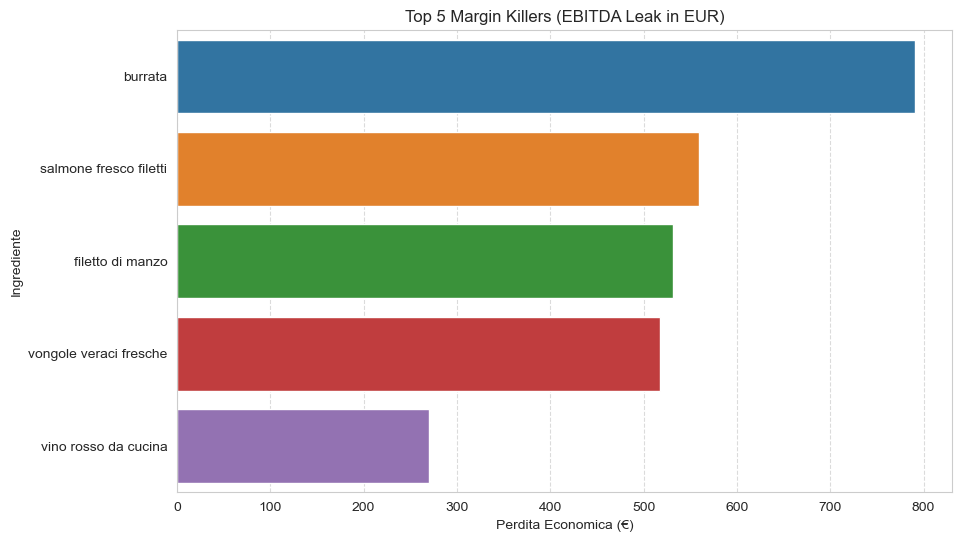

In [64]:
# filtering top 5 by absolute value of economic impact
top_leaks = leak_eur.sort_values('EBITDA_leak_eur', ascending=False).head(5)

# plotting information
plt.figure(figsize=(10, 6))
sns.barplot(data=top_leaks, x='EBITDA_leak_eur', y='nome_standard', hue='nome_standard', legend=False)
plt.title('Top 5 Margin Killers (EBITDA Leak in EUR)')
plt.xlabel('Perdita Economica (€)')
plt.ylabel('Ingrediente')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [65]:
# showing results
print(f"\n{'-'*65}")
print("SUMMARY EBITDA LEAK")
print(f"{'-'*65}")
print(f"Total EBITDA leak: €{leak_eur['EBITDA_leak_eur'].sum():.2f}")
print(f"N° ingredients with leak: {len(leak_eur)}")
print(f"Missing WAP: {leak_eur['wap'].isna().sum()}")
print(f"Ingredients average leak: €{leak_eur['EBITDA_leak_eur'].mean():.2f}")

# Check outliers
top5 = leak_eur.nlargest(5, 'EBITDA_leak_eur')
print(f"\nTop 5 leak:")
for _, row in top5.iterrows():
    qty_kg = row['Total_qty']
    wap = row['wap']
    leak_val = row['EBITDA_leak_eur']
    check = qty_kg * wap
    print(f"{row['nome_standard']:30s}: €{leak_val:7,.2f} " 
          f"({qty_kg:.2f} kg × €{wap:.2f}) {'✓' if abs(check - leak_val) < 0.01 else '❌'}")


-----------------------------------------------------------------
SUMMARY EBITDA LEAK
-----------------------------------------------------------------
Total EBITDA leak: €-71.73
N° ingredients with leak: 47
Missing WAP: 0
Ingredients average leak: €-1.53

Top 5 leak:
burrata                       : € 791.03 (33.49 kg × €23.62) ✓
salmone fresco filetti        : € 558.97 (33.98 kg × €16.45) ✓
filetto di manzo              : € 531.86 (14.68 kg × €36.23) ✓
vongole veraci fresche        : € 517.44 (53.51 kg × €9.67) ✓
vino rosso da cucina          : € 270.06 (42.00 kg × €6.43) ✓


## KEY FINDINGS & BUSINESS RECOMMENDATIONS

### **EBITDA Leak Analysis — February 2023**
**Note:** Single-month sample (Feb 2023). The pipeline is designed to be extended to a full monthly loop across the entire dataset (2023–2024).

**Top Waste Sources (Action Required):**
1. **Burrata**: € 791.03 (33.49 kg × €23.62) → Optimize order and inventory management while avoiding product expiring and deterioration
2. **Salmone Fresco Filetti**: € 558.97 (33.98 kg × €16.45) → Optimize the Mise en Place by avoiding wasting spoiled portions, be very careful when portioning to avoid excess weight
3. **Filetto di manzo**: € 531.86 (14.68 kg × €36.23) →Optimize the Mise en Place by avoiding wasting spoiled portions, be very careful when portioning to avoid excess weight

**Top Over-Portioning (real consumption < theoretical):**
- Negative leak = real usage below recipe standard
- Possible causes: under-portioning, inventory counting errors, recipe mismatch
- Recommended action: verify recipe accuracy before cost reduction

---

### **Food Cost % Insights — Full Dataset 2023–2024**
**Overall FC%: 19.9%** (below industry benchmark of 25–30% — driven by high-margin pasta and antipasti mix)

| Dish | FC% | Signal |
|---|---|---|
| Bistecca alla fiorentina | 41% | Premium — protect via pricing |
| Branzino al forno | 28% | Balanced |
| Spaghetti alle vongole | 9% | High-margin — upsell |
| Bruschette / Tagliere | 4–5% | High-margin — upsell |

---

### **Data Quality Improvements Implemented**
1. **Unit standardization** — resolved `bt`, `pz`, `cassa` inconsistencies across all 4 sources
2. **Fuzzy matching** — unified 150+ ingredient name variations against benchmark
3. **Outlier detection** — corrected price typos (e.g. €950/unit → €9.50)
4. **Benchmark price substitution** — replaced unrealistic synthetic costs with market prices (CAR Roma, ISMEA, CLAL)
5. **WAP fallback** — benchmark price applied where invoice data missing for the period

---

### **Next Steps for Production**
- [ ] Monthly loop — extend EBITDA leak to full 2023–2024 dataset
- [ ] Price anomaly flag — WARNING/CRITICAL at ±25% deviation from benchmark
- [ ] Automated alerts — trigger when single-ingredient leak > €500/month
- [ ] Dashboard — Tableau/PowerBI for real-time monitoring
- [ ] Forecasting — Prophet/ARIMA for predictive ordering